# 01 - EDA and Data Cleaning

## Women’s E-Commerce Clothing Reviews

Dans ce notebook, je vais réaliser la première partie de la démarche Data Mining
sur le jeu de données *Women’s E-Commerce Clothing Reviews*.

Les principales étapes sont :
- comprendre la structure des données ;
- analyser les types de variables ;
- étudier les valeurs manquantes ;
- détecter les doublons ;
- analyser les distributions ;
- détecter les valeurs aberrantes ;
- réaliser des tests statistiques ;
- nettoyer les données ;
- sauvegarder le dataset nettoyé.

La cible choisie pour le problème de classification est `Recommended IND`,
qui indique si la cliente recommande ou non le produit.

Je garde ici l’EDA et le nettoyage séparés du prétraitement final.
L’encodage des variables catégorielles et la standardisation seront réalisés
dans le notebook `02_preprocessing_encoding.ipynb`.

## 1. Importation des bibliothèques

J'importe les bibliothèques nécessaires pour :
- manipuler les données avec pandas ;
- effectuer les calculs numériques avec numpy ;
- réaliser les visualisations avec matplotlib et seaborn ;
- réaliser les tests statistiques avec scipy.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

## 2. Chargement du jeu de données

Je charge le fichier CSV depuis `data/raw/`.

Je conserve le fichier brut sans le modifier directement. Cela permet de garder
une séparation claire entre les données brutes et les données nettoyées.

In [3]:
from pathlib import Path


PROJECT_ROOT = Path("..")

DATA_FILENAME = "Womens Clothing E-Commerce Reviews.csv"
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "reviews.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset chargé avec succès.")
print(f"Chemin : {DATA_PATH}")

Dataset chargé avec succès.
Chemin : ..\data\raw\reviews.csv


## 3. Première exploration du dataset

In [4]:
# J'affiche quelques lignes pour comprendre la structure générale.
df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [5]:
# J'affiche également les dernières lignes.
df.tail()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
23481,23481,1104,34,Great dress for many occasions,I was very happy to snag this dress at such a ...,5,1,0,General Petite,Dresses,Dresses
23482,23482,862,48,Wish it was made of cotton,"It reminds me of maternity clothes. soft, stre...",3,1,0,General Petite,Tops,Knits
23483,23483,1104,31,"Cute, but see through","This fit well, but the top was very see throug...",3,0,1,General Petite,Dresses,Dresses
23484,23484,1084,28,"Very cute dress, perfect for summer parties an...",I bought this dress for a wedding i have this ...,3,1,2,General,Dresses,Dresses
23485,23485,1104,52,Please make more like this one!,This dress in a lovely platinum is feminine an...,5,1,22,General Petite,Dresses,Dresses


## 4. Vérification du volume des données

Le cahier des charges demande au minimum 10 000 observations brutes
et au moins 10 attributs.

Je vérifie explicitement ces deux conditions.

In [6]:
n_rows, n_cols = df.shape

print(f"Nombre de lignes : {n_rows}")
print(f"Nombre de colonnes : {n_cols}")

print("\nVérification du cahier des charges :")

if n_rows >= 10000:
    print("✓ Le dataset contient au moins 10 000 observations brutes.")
else:
    print("✗ Le dataset contient moins de 10 000 observations.")

if n_cols >= 10:
    print("✓ Le dataset contient au moins 10 attributs.")
else:
    print("✗ Le dataset contient moins de 10 attributs.")

Nombre de lignes : 23486
Nombre de colonnes : 11

Vérification du cahier des charges :
✓ Le dataset contient au moins 10 000 observations brutes.
✓ Le dataset contient au moins 10 attributs.


In [7]:
# Liste des attributs
print("Liste des variables :")

for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

Liste des variables :
1. Unnamed: 0
2. Clothing ID
3. Age
4. Title
5. Review Text
6. Rating
7. Recommended IND
8. Positive Feedback Count
9. Division Name
10. Department Name
11. Class Name


## 5. Suppression éventuelle d'une colonne d'index inutile

Certaines versions du fichier CSV peuvent contenir une colonne comme
`Unnamed: 0`, qui correspond simplement à un ancien index.

Je la supprime seulement si elle existe.

In [8]:
unnamed_cols = [
    col for col in df.columns
    if str(col).lower().startswith("unnamed")
]

if unnamed_cols:
    print("Colonnes d'index détectées :", unnamed_cols)
    df = df.drop(columns=unnamed_cols)
    print("✓ Colonnes d'index supprimées.")
else:
    print("✓ Aucune colonne d'index inutile détectée.")

Colonnes d'index détectées : ['Unnamed: 0']
✓ Colonnes d'index supprimées.


## 6. Informations générales

In [9]:
# Types de données, valeurs non nulles et mémoire utilisée.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Clothing ID              23486 non-null  int64 
 1   Age                      23486 non-null  int64 
 2   Title                    19676 non-null  object
 3   Review Text              22641 non-null  object
 4   Rating                   23486 non-null  int64 
 5   Recommended IND          23486 non-null  int64 
 6   Positive Feedback Count  23486 non-null  int64 
 7   Division Name            23472 non-null  object
 8   Department Name          23472 non-null  object
 9   Class Name               23472 non-null  object
dtypes: int64(5), object(5)
memory usage: 1.8+ MB


## 7. Identification de la nature des variables

La distinction entre variables quantitatives, catégorielles, textuelles
et cible est importante avant le nettoyage et le prétraitement.

- `Clothing ID` : identifiant.
- `Age` : quantitative.
- `Title` et `Review Text` : textuelles.
- `Rating` : ordinale.
- `Recommended IND` : binaire et cible.
- `Positive Feedback Count` : quantitative.
- `Division Name`, `Department Name`, `Class Name` : catégorielles.

In [10]:
variable_types = pd.DataFrame({
    "Variable": df.columns,
    "Type_Python": df.dtypes.astype(str).values,
    "Nombre_valeurs_uniques": [
        df[col].nunique(dropna=True) for col in df.columns
    ],
    "Valeurs_manquantes": [
        df[col].isna().sum() for col in df.columns
    ]
})

variable_types

,Variable,Type_Python,Nombre_valeurs_uniques,Valeurs_manquantes
0,Clothing ID,int64,1206,0
1,Age,int64,77,0
2,Title,object,13993,3810
3,Review Text,object,22634,845
4,Rating,int64,5,0
5,Recommended IND,int64,2,0
6,Positive Feedback Count,int64,82,0
7,Division Name,object,3,14
8,Department Name,object,6,14
9,Class Name,object,20,14


## 8. Vérification des doublons

In [11]:
duplicate_count = df.duplicated().sum()

print(f"Nombre de doublons exacts : {duplicate_count}")

if duplicate_count == 0:
    print("✓ Aucun doublon exact détecté.")
else:
    print("⚠ Des doublons exacts ont été détectés.")
    display(df[df.duplicated(keep=False)].head(20))

Nombre de doublons exacts : 21
⚠ Des doublons exacts ont été détectés.


,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
298,1104,39,NaN,NaN,5,1,0,General,Dresses,Dresses
493,1104,39,NaN,NaN,5,1,0,General,Dresses,Dresses
1004,1094,30,NaN,NaN,5,1,0,General,Dresses,Dresses
2739,1094,36,NaN,NaN,5,1,0,General Petite,Dresses,Dresses
2941,829,66,NaN,NaN,5,1,0,General Petite,Tops,Blouses
2959,1094,30,NaN,NaN,5,1,0,General,Dresses,Dresses
3961,895,36,NaN,NaN,5,1,0,General Petite,Tops,Fine gauge
3976,1078,35,NaN,NaN,5,1,0,General,Dresses,Dresses
4850,829,66,NaN,NaN,5,1,0,General Petite,Tops,Blouses
4866,834,70,NaN,NaN,5,1,0,General Petite,Tops,Blouses


## 9. Analyse des valeurs manquantes

Je calcule :
- le nombre de valeurs manquantes ;
- leur pourcentage ;
- le nombre de valeurs présentes.

Cette étape est nécessaire avant de décider d'une stratégie de traitement.

In [12]:
missing_table = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_Percentage": (df.isna().mean() * 100).round(2),
    "Non_Missing_Count": df.notna().sum()
}).sort_values(
    by="Missing_Percentage",
    ascending=False
)

missing_table

,Missing_Count,Missing_Percentage,Non_Missing_Count
Title,3810,16.22,19676
Review Text,845,3.60,22641
Class Name,14,0.06,23472
Division Name,14,0.06,23472
Department Name,14,0.06,23472
Clothing ID,0,0.00,23486
Age,0,0.00,23486
Rating,0,0.00,23486
Recommended IND,0,0.00,23486
Positive Feedback Count,0,0.00,23486


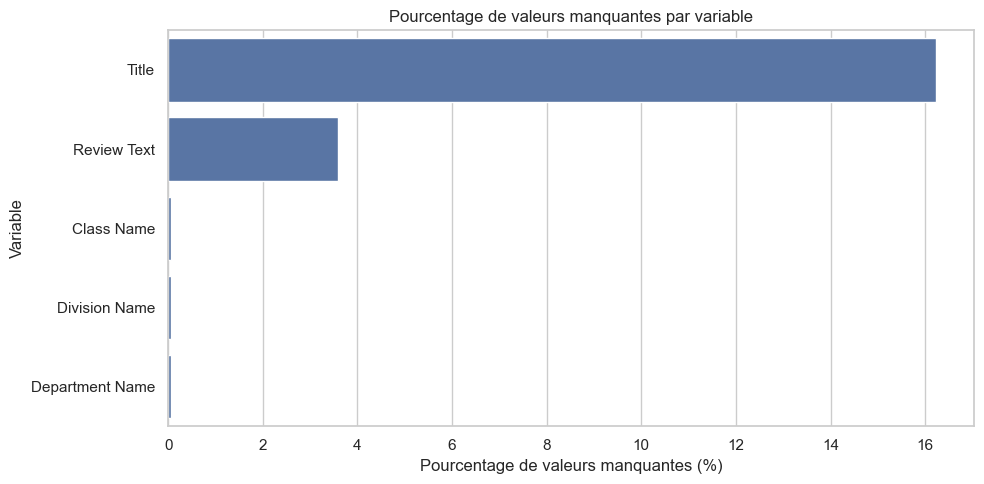

In [13]:
# Visualisation du taux de valeurs manquantes.
missing_plot = missing_table[missing_table["Missing_Count"] > 0]

if not missing_plot.empty:
    plt.figure(figsize=(10, 5))

    sns.barplot(
        x=missing_plot["Missing_Percentage"],
        y=missing_plot.index
    )

    plt.xlabel("Pourcentage de valeurs manquantes (%)")
    plt.ylabel("Variable")
    plt.title("Pourcentage de valeurs manquantes par variable")
    plt.tight_layout()
    plt.show()
else:
    print("✓ Aucune valeur manquante détectée.")

## 10. Statistiques descriptives

In [14]:
# Statistiques descriptives des variables numériques.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Clothing ID,23486.0,918.118709,203.298980,0.0,861.0,936.0,1078.0,1205.0
Age,23486.0,43.198544,12.279544,18.0,34.0,41.0,52.0,99.0
Rating,23486.0,4.196032,1.110031,1.0,4.0,5.0,5.0,5.0
Recommended IND,23486.0,0.822362,0.382216,0.0,1.0,1.0,1.0,1.0
Positive Feedback Count,23486.0,2.535936,5.702202,0.0,0.0,1.0,3.0,122.0


In [15]:
# Statistiques descriptives de toutes les variables.
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Clothing ID,23486.0,NaN,NaN,NaN,918.118709,203.29898,0.0,861.0,936.0,1078.0,1205.0
Age,23486.0,NaN,NaN,NaN,43.198544,12.279544,18.0,34.0,41.0,52.0,99.0
Title,19676,13993,Love it!,136,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Review Text,22641,22634,Perfect fit and i've gotten so many compliment...,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rating,23486.0,NaN,NaN,NaN,4.196032,1.110031,1.0,4.0,5.0,5.0,5.0
Recommended IND,23486.0,NaN,NaN,NaN,0.822362,0.382216,0.0,1.0,1.0,1.0,1.0
Positive Feedback Count,23486.0,NaN,NaN,NaN,2.535936,5.702202,0.0,0.0,1.0,3.0,122.0
Division Name,23472,3,General,13850,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Department Name,23472,6,Tops,10468,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Class Name,23472,20,Dresses,6319,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 11. Analyse de la variable cible

La variable cible de notre problème de classification est `Recommended IND`.

Je vérifie la fréquence absolue et relative des deux classes afin de voir
si les classes sont équilibrées ou déséquilibrées.

In [16]:
TARGET_COL = "Recommended IND"

if TARGET_COL not in df.columns:
    raise KeyError(f"La colonne cible '{TARGET_COL}' n'existe pas dans le dataset.")

target_counts = df[TARGET_COL].value_counts().sort_index()
target_percent = (
    df[TARGET_COL]
    .value_counts(normalize=True)
    .sort_index() * 100
)

target_distribution = pd.DataFrame({
    "Nombre": target_counts,
    "Pourcentage": target_percent.round(2)
})

target_distribution

,Nombre,Pourcentage
Recommended IND,,
0,4172,17.76
1,19314,82.24


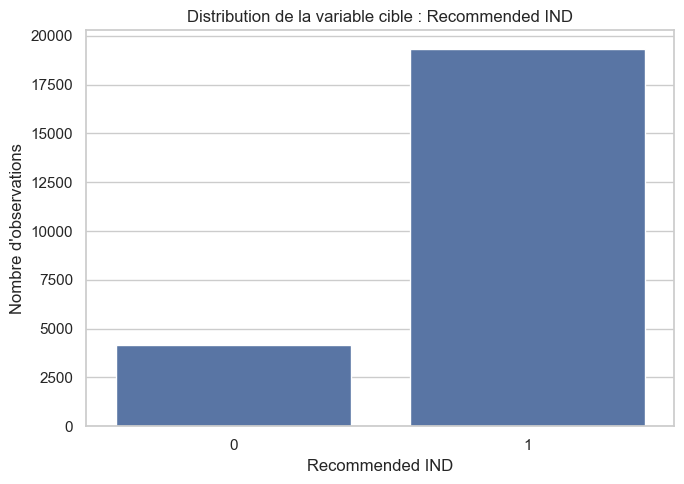

In [17]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x=TARGET_COL
)

plt.title("Distribution de la variable cible : Recommended IND")
plt.xlabel("Recommended IND")
plt.ylabel("Nombre d'observations")
plt.tight_layout()
plt.show()

## 12. Distribution des variables numériques

Je visualise les variables quantitatives avec des histogrammes et les courbes KDE.

Cela permet d'observer :
- la forme de la distribution ;
- la dispersion ;
- l'asymétrie ;
- d'éventuelles valeurs extrêmes.

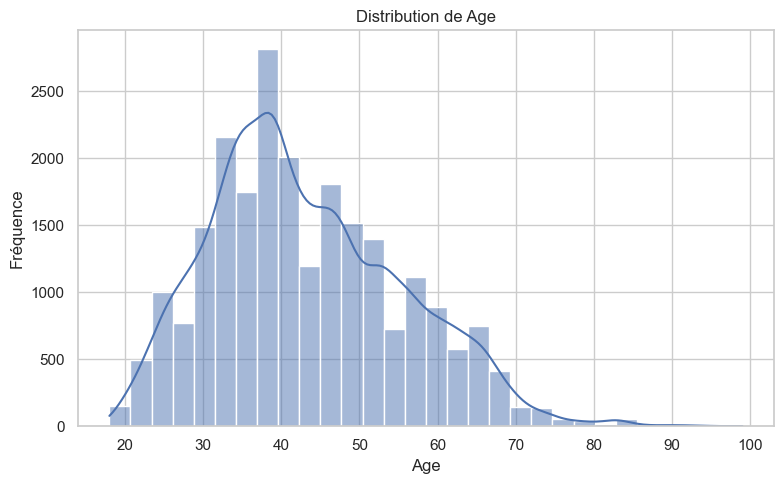

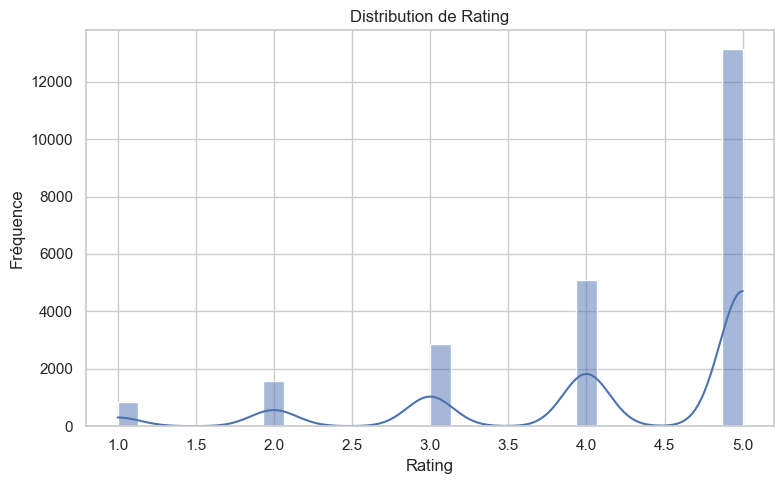

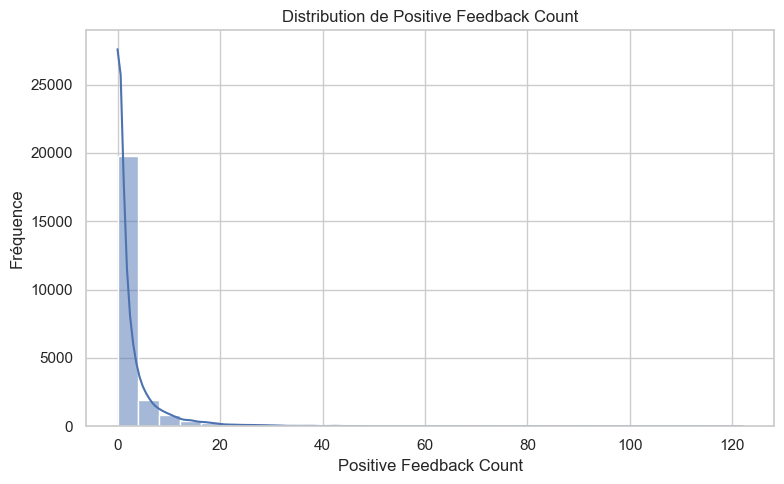

In [18]:
numeric_candidates = [
    "Age",
    "Rating",
    "Positive Feedback Count"
]

numeric_cols = [
    col for col in numeric_candidates
    if col in df.columns
]

for col in numeric_cols:
    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df,
        x=col,
        kde=True,
        bins=30
    )

    plt.title(f"Distribution de {col}")
    plt.xlabel(col)
    plt.ylabel("Fréquence")
    plt.tight_layout()
    plt.show()

## 13. Détection des valeurs aberrantes avec la règle de Tukey

Je vais utiliser l'IQR (Interquartile Range).

Une observation est potentiellement aberrante si :

`x < Q1 - 1.5 × IQR`

ou

`x > Q3 + 1.5 × IQR`.

Important : un outlier n'est pas automatiquement une erreur.
Je vais donc le détecter avant de décider d'un éventuel traitement.

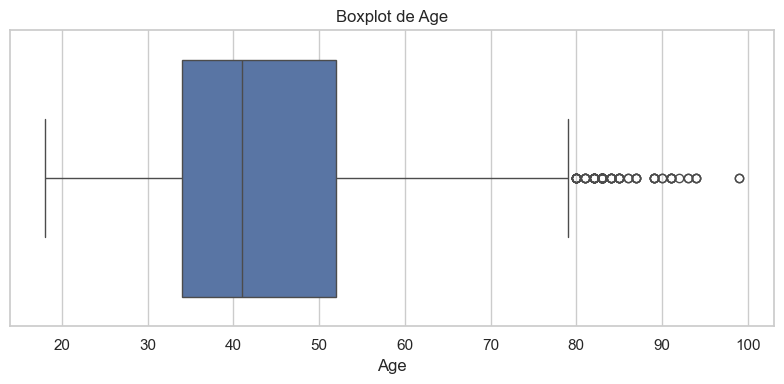

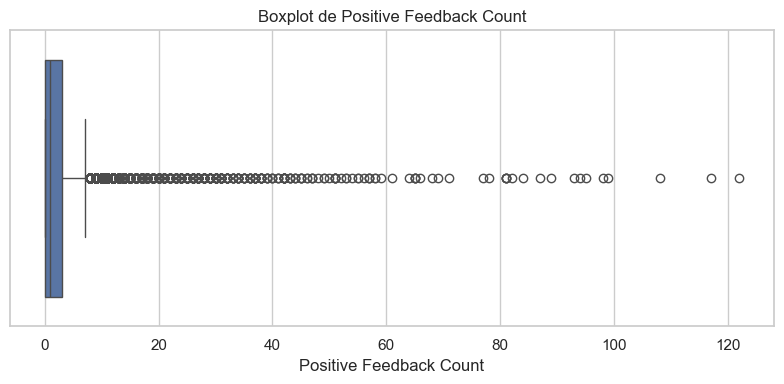

In [19]:
outlier_candidates = [
    col for col in ["Age", "Positive Feedback Count"]
    if col in df.columns
]

for col in outlier_candidates:
    plt.figure(figsize=(8, 4))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

In [20]:
def detect_iqr_outliers(data, column):
    # Détection des valeurs potentiellement aberrantes avec la règle de Tukey.
    series = data[column].dropna()

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    mask = (
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    )

    return {
        "Variable": column,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Nombre_Outliers": int(mask.sum()),
        "Pourcentage_Outliers": round(mask.mean() * 100, 2)
    }


outlier_results = pd.DataFrame([
    detect_iqr_outliers(df, col)
    for col in outlier_candidates
])

outlier_results

,Variable,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Nombre_Outliers,Pourcentage_Outliers
0,Age,34.0,52.0,18.0,7.0,79.0,109,0.46
1,Positive Feedback Count,0.0,3.0,3.0,-4.5,7.5,2147,9.14


## 14. Analyse des variables catégorielles

Je regarde les fréquences des principales variables qualitatives.

Cette étape permet de vérifier :
- les modalités présentes ;
- les catégories dominantes ;
- d'éventuelles modalités inattendues ;
- la distribution avant l'encodage futur.

In [22]:
categorical_cols = [
    col for col in [
        "Division Name",
        "Department Name",
        "Class Name"
    ]
    if col in df.columns
]

for col in categorical_cols:
    print("=" * 70)
    print(f"Variable : {col}")
    print("=" * 70)

    display(
        df[col]
        .value_counts(dropna=False)
        .head(15)
        .to_frame("Count")
    )

Variable : Division Name


,Count
Division Name,
General,13850
General Petite,8120
Initmates,1502
NaN,14


Variable : Department Name


,Count
Department Name,
Tops,10468
Dresses,6319
Bottoms,3799
Intimate,1735
Jackets,1032
Trend,119
NaN,14


Variable : Class Name


,Count
Class Name,
Dresses,6319
Knits,4843
Blouses,3097
Sweaters,1428
Pants,1388
Jeans,1147
Fine gauge,1100
Skirts,945
Jackets,704


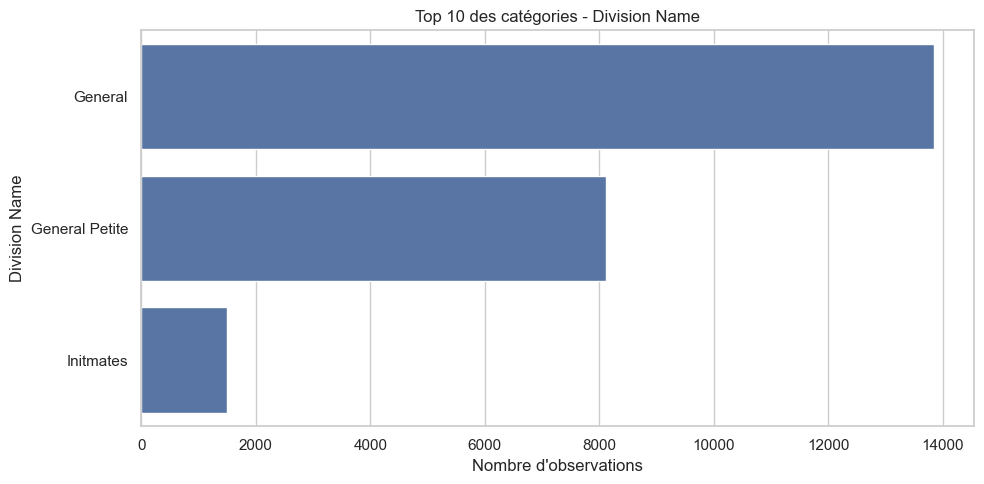

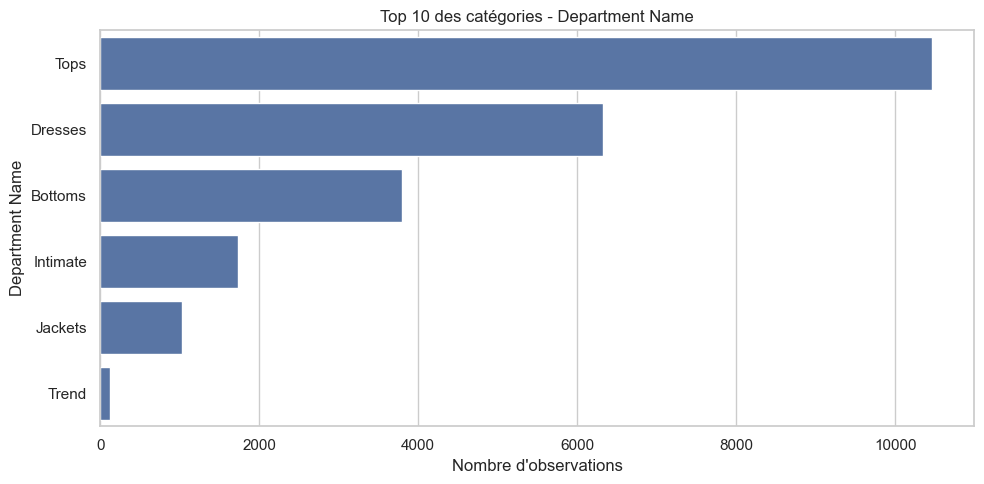

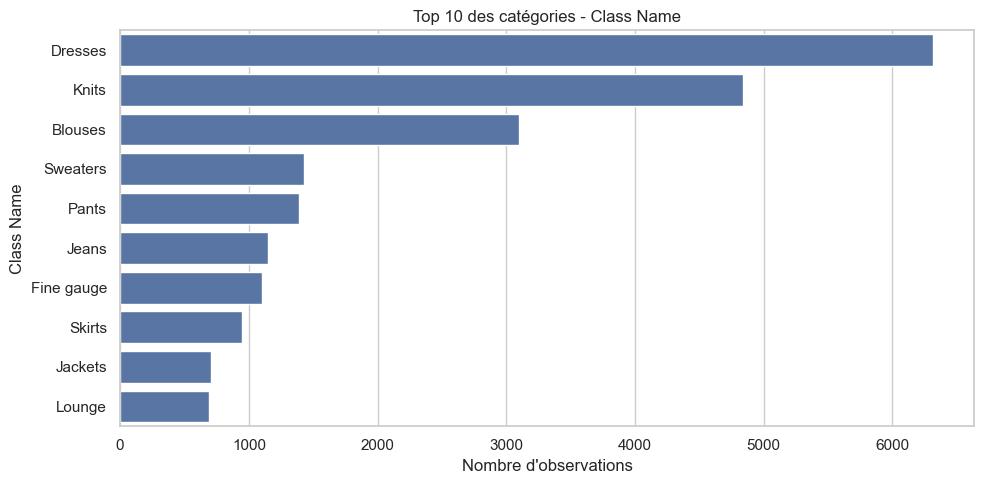

In [23]:
for col in categorical_cols:
    plt.figure(figsize=(10, 5))

    order = df[col].value_counts().head(10).index

    sns.countplot(
        data=df,
        y=col,
        order=order
    )

    plt.title(f"Top 10 des catégories - {col}")
    plt.xlabel("Nombre d'observations")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

## 15. Matrice de corrélation

Je calcule la corrélation de Pearson entre les variables numériques.

Cette analyse permet également d'identifier d'éventuelles relations très
fortes entre variables.

In [24]:
corr_candidates = [
    "Age",
    "Rating",
    "Positive Feedback Count",
    TARGET_COL
]

corr_cols = [
    col for col in corr_candidates
    if col in df.columns
]

corr_matrix = df[corr_cols].corr(method="pearson")

corr_matrix

,Age,Rating,Positive Feedback Count,Recommended IND
Age,1.000000,0.026831,0.043079,0.030622
Rating,0.026831,1.000000,-0.064961,0.792336
Positive Feedback Count,0.043079,-0.064961,1.000000,-0.069045
Recommended IND,0.030622,0.792336,-0.069045,1.000000


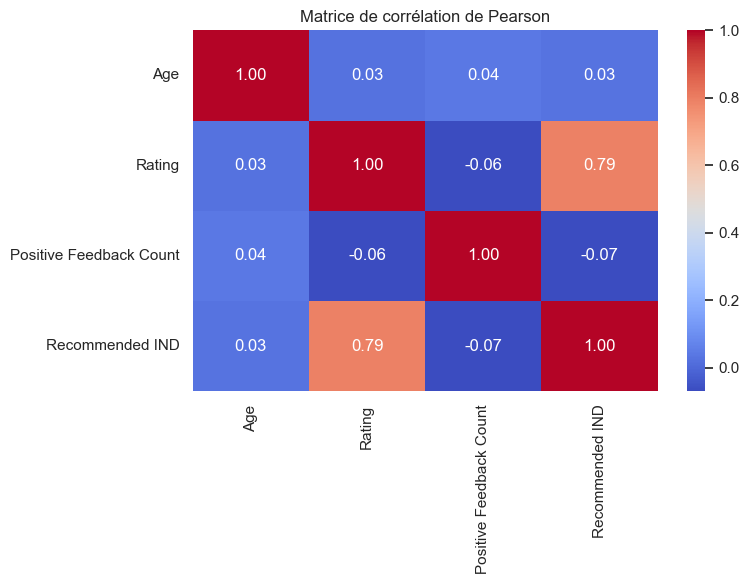

In [25]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matrice de corrélation de Pearson")
plt.tight_layout()
plt.show()

## 16. Test statistique 1 — Mann-Whitney U

### Question

La distribution de `Rating` est-elle différente entre :
- les clientes qui recommandent (`Recommended IND = 1`) ;
- les clientes qui ne recommandent pas (`Recommended IND = 0`) ?

### Hypothèses

- H0 : les distributions de `Rating` sont similaires dans les deux groupes.
- H1 : les distributions de `Rating` sont différentes.

### Justification

`Rating` est une variable ordinale comprise entre 1 et 5 et nous comparons
deux groupes indépendants. Je choisis donc le test non paramétrique
de Mann-Whitney U.

Le seuil de significativité est fixé à α = 0.05.

In [26]:
rating_recommended = df.loc[
    df[TARGET_COL] == 1,
    "Rating"
].dropna()

rating_not_recommended = df.loc[
    df[TARGET_COL] == 0,
    "Rating"
].dropna()

u_stat, p_value_mw = stats.mannwhitneyu(
    rating_recommended,
    rating_not_recommended,
    alternative="two-sided"
)

print(f"Taille du groupe Recommended = 1 : {len(rating_recommended)}")
print(f"Taille du groupe Recommended = 0 : {len(rating_not_recommended)}")
print(f"Statistique U : {u_stat:.2f}")
print(f"p-value : {p_value_mw:.6g}")

Taille du groupe Recommended = 1 : 19314
Taille du groupe Recommended = 0 : 4172
Statistique U : 78344145.00
p-value : 0


In [27]:
alpha = 0.05

if p_value_mw < alpha:
    print(
        "Conclusion : p-value < 0.05. "
        "On rejette H0 : les distributions de Rating diffèrent "
        "statistiquement entre les deux groupes."
    )
else:
    print(
        "Conclusion : p-value >= 0.05. "
        "On ne rejette pas H0 : les données ne permettent pas "
        "de conclure à une différence statistiquement significative."
    )

median_comparison = pd.DataFrame({
    "Groupe": [
        "Recommended IND = 0",
        "Recommended IND = 1"
    ],
    "Médiane_Rating": [
        rating_not_recommended.median(),
        rating_recommended.median()
    ],
    "Taille": [
        len(rating_not_recommended),
        len(rating_recommended)
    ]
})

median_comparison

Conclusion : p-value < 0.05. On rejette H0 : les distributions de Rating diffèrent statistiquement entre les deux groupes.


,Groupe,Médiane_Rating,Taille
0,Recommended IND = 0,2.0,4172
1,Recommended IND = 1,5.0,19314


## 17. Test statistique 2 — Chi-square d'indépendance

### Question

Existe-t-il une association statistique entre :
- `Department Name` ;
- `Recommended IND` ?

### Hypothèses

- H0 : les deux variables sont indépendantes.
- H1 : les deux variables sont associées.

### Justification

Les deux variables sont qualitatives, donc le test du χ² d'indépendance
est adapté.

Le seuil de significativité est fixé à α = 0.05.

In [28]:
department_col = "Department Name"

if department_col in df.columns:

    contingency_table = pd.crosstab(
        df[department_col],
        df[TARGET_COL]
    )

    contingency_table
else:
    raise KeyError(f"La colonne '{department_col}' n'existe pas.")

In [29]:
chi2_stat, p_value_chi2, dof, expected = stats.chi2_contingency(
    contingency_table
)

print(f"Statistique du χ² : {chi2_stat:.2f}")
print(f"Degrés de liberté : {dof}")
print(f"p-value : {p_value_chi2:.6g}")

Statistique du χ² : 50.24
Degrés de liberté : 5
p-value : 1.23561e-09


In [30]:
alpha = 0.05

if p_value_chi2 < alpha:
    print(
        "Conclusion : p-value < 0.05. "
        "On rejette H0 : il existe une association statistiquement "
        "significative entre Department Name et Recommended IND."
    )
else:
    print(
        "Conclusion : p-value >= 0.05. "
        "On ne rejette pas H0 : aucune association statistiquement "
        "significative n'est mise en évidence."
    )

Conclusion : p-value < 0.05. On rejette H0 : il existe une association statistiquement significative entre Department Name et Recommended IND.


## 18. Résumé des tests statistiques

Je rassemble les résultats des deux tests demandés par le cahier des charges.

Une p-value significative montre une différence ou une association statistique.
Elle ne signifie pas automatiquement qu'une variable est la cause de l'autre.

In [31]:
statistical_results = pd.DataFrame({
    "Test": [
        "Mann-Whitney U",
        "Chi-square d'indépendance"
    ],
    "Variable(s)": [
        "Rating vs Recommended IND",
        "Department Name vs Recommended IND"
    ],
    "Statistique": [
        u_stat,
        chi2_stat
    ],
    "p_value": [
        p_value_mw,
        p_value_chi2
    ],
    "Alpha": [
        0.05,
        0.05
    ],
    "Decision": [
        "Rejet de H0" if p_value_mw < 0.05 else "Non-rejet de H0",
        "Rejet de H0" if p_value_chi2 < 0.05 else "Non-rejet de H0"
    ]
})

statistical_results

,Test,Variable(s),Statistique,p_value,Alpha,Decision
0,Mann-Whitney U,Rating vs Recommended IND,7.834414e+07,0.000000e+00,0.05,Rejet de H0
1,Chi-square d'indépendance,Department Name vs Recommended IND,5.024343e+01,1.235608e-09,0.05,Rejet de H0


# 19. Début du nettoyage

Je crée une copie du dataset afin de conserver les données brutes intactes.

Le nettoyage comprend :
- suppression des doublons exacts ;
- nettoyage des espaces inutiles ;
- traitement des chaînes vides ;
- traitement des catégories manquantes ;
- traitement des textes manquants ;
- vérification de la cible.

L'imputation numérique finale et la standardisation seront réalisées ensuite
dans le pipeline de prétraitement, après le split train/test, afin d'éviter
la fuite de données.

In [32]:
df_clean = df.copy()

print(f"Dimensions initiales : {df_clean.shape}")

Dimensions initiales : (23486, 10)


## 20. Suppression des doublons

In [33]:
before_duplicates = len(df_clean)

df_clean = (
    df_clean
    .drop_duplicates()
    .reset_index(drop=True)
)

after_duplicates = len(df_clean)

print(f"Lignes avant suppression des doublons : {before_duplicates}")
print(f"Lignes après suppression des doublons  : {after_duplicates}")
print(
    f"Doublons supprimés                      : "
    f"{before_duplicates - after_duplicates}"
)

Lignes avant suppression des doublons : 23486
Lignes après suppression des doublons  : 23465
Doublons supprimés                      : 21


## 21. Nettoyage des espaces

In [34]:
text_like_cols = [
    col for col in [
        "Title",
        "Review Text",
        "Division Name",
        "Department Name",
        "Class Name"
    ]
    if col in df_clean.columns
]

for col in text_like_cols:
    df_clean[col] = df_clean[col].apply(
        lambda x: x.strip() if isinstance(x, str) else x
    )

print("✓ Nettoyage des espaces terminé.")

✓ Nettoyage des espaces terminé.


## 22. Transformation des chaînes vides en valeurs manquantes

Les chaînes vides sont transformées en `NaN` afin d'être traitées
correctement dans l'étape de nettoyage.

In [35]:
for col in text_like_cols:
    df_clean[col] = df_clean[col].replace(
        r"^\s*$",
        np.nan,
        regex=True
    )

print("✓ Les chaînes vides ont été converties en NaN.")

✓ Les chaînes vides ont été converties en NaN.


## 23. Vérification des valeurs manquantes après nettoyage de base

In [36]:
missing_after_basic_cleaning = pd.DataFrame({
    "Missing_Count": df_clean.isna().sum(),
    "Missing_Percentage": (
        df_clean.isna().mean() * 100
    ).round(2)
})

missing_after_basic_cleaning

,Missing_Count,Missing_Percentage
Clothing ID,0,0.00
Age,0,0.00
Title,3789,16.15
Review Text,825,3.52
Rating,0,0.00
Recommended IND,0,0.00
Positive Feedback Count,0,0.00
Division Name,14,0.06
Department Name,14,0.06
Class Name,14,0.06


## 24. Traitement des variables catégorielles manquantes

Pour les variables catégorielles, je remplace les valeurs manquantes
par `Unknown`.

Je préfère conserver les lignes plutôt que les supprimer automatiquement,
car les autres informations de ces observations peuvent rester utiles.

In [37]:
categorical_to_clean = [
    col for col in [
        "Division Name",
        "Department Name",
        "Class Name"
    ]
    if col in df_clean.columns
]

for col in categorical_to_clean:
    df_clean[col] = df_clean[col].fillna("Unknown")

print("✓ Valeurs manquantes catégorielles remplacées par 'Unknown'.")

✓ Valeurs manquantes catégorielles remplacées par 'Unknown'.


## 25. Traitement des variables textuelles

L'absence de `Title` ou de `Review Text` ne signifie pas nécessairement
que l'observation est invalide.

Je conserve donc les observations et remplace ces valeurs par une chaîne vide.

In [38]:
text_columns = [
    col for col in ["Title", "Review Text"]
    if col in df_clean.columns
]

for col in text_columns:
    df_clean[col] = df_clean[col].fillna("")

print("✓ Valeurs manquantes des variables textuelles traitées.")

✓ Valeurs manquantes des variables textuelles traitées.


## 26. Vérification de la cohérence des variables numériques

Je m'assure que les variables numériques importantes ont bien un type
numérique.

Je ne supprime pas ici les valeurs extrêmes uniquement parce qu'elles sont
des outliers : elles doivent être interprétées avant toute suppression.

In [39]:
numeric_cols_clean = [
    col for col in [
        "Age",
        "Rating",
        "Recommended IND",
        "Positive Feedback Count"
    ]
    if col in df_clean.columns
]

for col in numeric_cols_clean:
    df_clean[col] = pd.to_numeric(
        df_clean[col],
        errors="coerce"
    )

print("✓ Conversion des variables numériques terminée.")

✓ Conversion des variables numériques terminée.


In [40]:
if "Rating" in df_clean.columns:
    print("Valeurs présentes dans Rating :")
    print(sorted(df_clean["Rating"].dropna().unique()))

if TARGET_COL in df_clean.columns:
    print("\nValeurs présentes dans Recommended IND :")
    print(sorted(df_clean[TARGET_COL].dropna().unique()))

Valeurs présentes dans Rating :
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Valeurs présentes dans Recommended IND :
[np.int64(0), np.int64(1)]


## 27. Traitement de la cible manquante

Une observation dont la cible `Recommended IND` est absente ne peut pas être
utilisée directement pour l'apprentissage supervisé.

Je supprime donc uniquement les lignes où la cible est manquante.

In [41]:
missing_target = df_clean[TARGET_COL].isna().sum()

print(
    f"Nombre de valeurs manquantes dans la cible : {missing_target}"
)

before_target_cleaning = len(df_clean)

df_clean = (
    df_clean
    .dropna(subset=[TARGET_COL])
    .reset_index(drop=True)
)

after_target_cleaning = len(df_clean)

print(
    f"Lignes supprimées car la cible était manquante : "
    f"{before_target_cleaning - after_target_cleaning}"
)

Nombre de valeurs manquantes dans la cible : 0
Lignes supprimées car la cible était manquante : 0


## 28. Valeurs numériques encore manquantes

Je vérifie les variables numériques.

Je n'impute pas encore automatiquement avec la médiane sur tout le dataset.
Dans le prochain notebook, l'imputation sera faite à l'intérieur du pipeline
d'apprentissage afin que les statistiques d'imputation soient calculées
sur le jeu d'entraînement uniquement.

In [42]:
numeric_missing = pd.DataFrame({
    "Variable": numeric_cols_clean,
    "Missing_Count": [
        df_clean[col].isna().sum()
        for col in numeric_cols_clean
    ],
    "Missing_Percentage": [
        round(df_clean[col].isna().mean() * 100, 2)
        for col in numeric_cols_clean
    ]
})

numeric_missing

,Variable,Missing_Count,Missing_Percentage
0,Age,0,0.0
1,Rating,0,0.0
2,Recommended IND,0,0.0
3,Positive Feedback Count,0,0.0


## 29. Nouvelle détection des outliers après nettoyage

In [43]:
outlier_candidates_clean = [
    col for col in [
        "Age",
        "Positive Feedback Count"
    ]
    if col in df_clean.columns
]

outlier_results_clean = pd.DataFrame([
    detect_iqr_outliers(df_clean, col)
    for col in outlier_candidates_clean
])

outlier_results_clean

,Variable,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Nombre_Outliers,Pourcentage_Outliers
0,Age,34.0,52.0,18.0,7.0,79.0,109,0.46
1,Positive Feedback Count,0.0,3.0,3.0,-4.5,7.5,2147,9.15


## 30. Vérification finale de la qualité des données

In [44]:
print("===== VÉRIFICATION FINALE =====")

print(f"Nombre de lignes : {df_clean.shape[0]}")
print(f"Nombre de colonnes : {df_clean.shape[1]}")

print(f"\nNombre de doublons : {df_clean.duplicated().sum()}")

print("\nValeurs manquantes :")
display(
    df_clean.isna().sum().to_frame("Missing_Count")
)

print("\nTypes des variables :")
display(
    df_clean.dtypes.to_frame("Data_Type")
)

===== VÉRIFICATION FINALE =====
Nombre de lignes : 23465
Nombre de colonnes : 10

Nombre de doublons : 0

Valeurs manquantes :


,Missing_Count
Clothing ID,0
Age,0
Title,0
Review Text,0
Rating,0
Recommended IND,0
Positive Feedback Count,0
Division Name,0
Department Name,0
Class Name,0



Types des variables :


,Data_Type
Clothing ID,int64
Age,int64
Title,object
Review Text,object
Rating,int64
Recommended IND,int64
Positive Feedback Count,int64
Division Name,object
Department Name,object
Class Name,object


In [45]:
# Aperçu du dataset après nettoyage.
df_clean.head(10)

,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,767,33,,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1080,34,,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses
5,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",2,0,4,General,Dresses,Dresses
6,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,5,1,1,General Petite,Tops,Knits
7,858,39,"Shimmer, surprisingly goes with lots","I ordered this in carbon for store pick up, an...",4,1,4,General Petite,Tops,Knits
8,1077,24,Flattering,I love this dress. i usually get an xs but it ...,5,1,0,General,Dresses,Dresses
9,1077,34,Such a fun dress!,"I'm 5""5' and 125 lbs. i ordered the s petite t...",5,1,0,General,Dresses,Dresses


## 31. Comparaison avant / après nettoyage

In [46]:
cleaning_summary = pd.DataFrame({
    "Étape": [
        "Dataset brut",
        "Après suppression des doublons",
        "Après nettoyage"
    ],
    "Nombre_de_lignes": [
        len(df),
        len(df.drop_duplicates()),
        len(df_clean)
    ]
})

cleaning_summary

,Étape,Nombre_de_lignes
0,Dataset brut,23486
1,Après suppression des doublons,23465
2,Après nettoyage,23465


## 32. Sauvegarde du dataset nettoyé

Le fichier brut reste dans `data/raw/`.

Le fichier nettoyé est enregistré dans `data/processed/`.

In [47]:
OUTPUT_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "reviews_clean.csv"
)

OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

df_clean.to_csv(
    OUTPUT_PATH,
    index=False
)

print(f"✓ Dataset nettoyé sauvegardé dans : {OUTPUT_PATH}")

✓ Dataset nettoyé sauvegardé dans : ..\data\processed\reviews_clean.csv


# Conclusion

Dans ce notebook, j'ai réalisé :

- la compréhension générale du dataset ;
- les statistiques descriptives ;
- l'analyse des valeurs manquantes ;
- la détection des doublons ;
- l'analyse de la variable cible ;
- les histogrammes et KDE ;
- les boxplots et la détection des outliers avec l'IQR ;
- l'analyse des variables catégorielles ;
- la corrélation de Pearson ;
- le test de Mann-Whitney U ;
- le test du χ² d'indépendance ;
- le nettoyage des doublons et des chaînes ;
- le traitement des valeurs manquantes catégorielles et textuelles ;
- la vérification de la cible ;
- la vérification finale de la qualité des données ;
- la sauvegarde du dataset nettoyé.

Le résultat sera utilisé dans `02_preprocessing_encoding.ipynb`.

L'encodage One-Hot, l'imputation numérique intégrée au pipeline et la
standardisation/normalisation seront réalisés dans l'étape suivante.